<a href="https://colab.research.google.com/github/academiaturkiye/academiaturkiye.github.io/blob/main/mesa/teknik%20ajanlar/temel-teknik-gurultu%20oranlar%C4%B1-%20fibonacci-03.06.2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

-----TEMEL AJANLAR ---------

- Temel Etki (anında)
- Asimetrik Etki (anında)
- Güçlenen Etki (gecikmeli-hafızalı)
- Sönümlü Etki (gecikmeli-hafızalı)

ANINDA ETKİ VS GECİKMELİ ETKİ

- Haber/bilgi olumlu/olumsuz iken hangisi (anında/gecikmeli), piyasayı tersi yönde götürebiliyor ya da dirençli yapabiliyor? Hangi oran bunu sağlıyor?

- Kümülatif haber grafiği ile ters hareket eden oran hangisidir?

- Birinci deneyde anında = gecikmeli

- İkinci deneyde anında eşit değil gecikmeli



In [1]:
!pip install mesa[rec]
!pip install seaborn

# Has multi-dimensional arrays and matrices.
# Has a large collection of mathematical functions to operate on these arrays.
import numpy as np

# Data manipulation and analysis.
import pandas as pd

# Data visualization tools.
import seaborn as sns

import mesa

import random


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.0/197.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.8/265.8 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.8/72.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 454.8/454.8 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 43.2 MB/s eta 0:00:00


In [150]:
import random

# === FUNDAMENTAL AGENT STRATEGIES ===
def fundamental_strategy_0(agent, model):
    #Temel Etki
    #print(f"Fundamental_strategy_0 aktif")
    if model.price < model.fundamental_value_0:
        return "buy"
    elif model.price > model.fundamental_value_0:
        return "sell"
    return "hold"

def fundamental_strategy_1(agent, model):
    # Asimetrik
    #print(f"Fundamental_strategy_1 aktif")
    if model.price < model.fundamental_value_1:
        return "buy"
    elif model.price > model.fundamental_value_1:
        return "sell"
    return "hold"

def fundamental_strategy_2(agent, model):
    # Güçlenen
    #print(f"Fundamental_strategy_2 aktif")
    if model.price < model.fundamental_value_2:
            return "buy"
    elif model.price > model.fundamental_value_2:
            return "sell"
    return "hold"

def fundamental_strategy_3(agent, model):
    # Sönümlü
    #print(f"Fundamental_strategy_3 aktif")
    if model.price < model.fundamental_value_3:
        return "buy"
    elif model.price > model.fundamental_value_3:
        return "sell"
    return "hold"




fundamental_strategies = [
    fundamental_strategy_0,
    #fundamental_strategy_1,
    #fundamental_strategy_2,
    #fundamental_strategy_3
]

# === TECHNICAL AGENT STRATEGIES ===
def technical_strategy_0(agent, model): # Fibonacci-altın oran

    # Calculate Fibonacci lines based on the current price history
    max_price = np.max(model.price_history) if model.price_history else model.price
    min_price = np.min(model.price_history) if model.price_history else model.price
    fib_levels = [0.0, 0.236, 0.382, 0.5, 0.618, 1.0]
    fib_lines = [max_price - (max_price - min_price) * level for level in fib_levels]

    # Check current price against Fibonacci lines
    if model.price < fib_lines[4]:  # 0.618 seviyesi
        model.buy_signals.append((model.step_count, model.price))
        return "buy"
    elif model.price > fib_lines[2]:  # 0.382 seviyesi
        model.sell_signals.append((model.step_count, model.price))
        return "sell"
    else:
        return "hold"

def technical_strategy_1(agent, model):

    """Trend Dönüşü: Son üç fiyatı analiz et."""
    history = model.price_history
    if len(history) >= 3:
        if history[-1] > history[-2] > history[-3]:
            return "buy"
        elif history[-1] < history[-2] < history[-3]:
            return "sell"
    return "hold"


def technical_strategy_2(agent, model):

    threshold = random.uniform(0.10, 0.30)
    son_fiyatlar = model.price_history[-agent.price_window:]
    momentum = (son_fiyatlar[-1] - son_fiyatlar[0]) / son_fiyatlar[0]

    if momentum > threshold:
        print(f"step count: {model.step_count} - Ajan-ID: {agent.unique_id} alış yaptı. Momentum: {momentum} - threshold: {threshold}")

        return "buy"
    elif momentum < -threshold:
        print(f"step count: {model.step_count} - Ajan-ID: {agent.unique_id} satış yaptı. Momentum: {momentum} - threshold: {threshold}")

        return "sell"
    return "hold"



def technical_strategy_3(agent, model):

    """Rastgele Momentum: %60 ihtimalle trend takibi"""
    if random.random() < 0.6:
        return technical_strategy_0(agent, model)
    else:
        return "hold"


technical_strategies = [
    #technical_strategy_0,
    technical_strategy_1,
    technical_strategy_2,
    technical_strategy_3
]

# === NOISE AGENT STRATEGIES ===
def noise_strategy_0(agent, model):
    """Rastgele işlem."""
    return random.choice(["buy", "sell", "hold"])

def noise_strategy_1(agent, model):
    """Daha çok hold eğilimli rastgele işlem."""
    return random.choices(["buy", "sell", "hold"], weights=[0.2, 0.2, 0.6])[0]

def noise_strategy_2(agent, model):
    """Fiyatın çift/tek olmasına göre karar verir."""
    if int(model.price) % 2 == 0:
        return "buy"
    else:
        return "sell"

def noise_strategy_3(agent, model):
    """Rastgele ancak varlığı olanlar daha çok satar."""
    if agent.asset > 0 and random.random() < 0.6:
        return "sell"
    return random.choice(["buy", "hold"])

noise_strategies = [
    noise_strategy_0,
    noise_strategy_1,
    noise_strategy_2,
    noise_strategy_3
]

##############################----------AGENT--------------#######################

class BaseAgent(mesa.Agent):
    def __init__(self, model, agent_type, strategy_id):
        super().__init__(model)
        self.agent_type = agent_type  # 'fundamental', 'technical', 'noise'
        self.strategy_id = strategy_id  # 0, 1, 2, 3 (her tür için 4 strateji)
        self.cash = 100000.0
        self.asset = 1000
        self.last_action = None  # 'buy', 'sell', 'hold'
        self.price_window = int(random.uniform(3, 5))

    def step(self):
        raise NotImplementedError("This method should be implemented by subclasses.")


class FundamentalAgent(BaseAgent):
    def __init__(self, model, strategy_id):
        super().__init__(model, "fundamental", strategy_id)

    def step(self):
        #from strategies import fundamental_strategies
        action = fundamental_strategies[self.strategy_id](self, self.model)
        self.execute_action(action)

    def execute_action(self, action):
        price = self.model.price
        if action == "buy" and self.cash >= price:
            self.asset += 1
            self.cash -= price
            self.model.total_demand += 1
        elif action == "sell" and self.asset > 0:
            self.asset -= 1
            self.cash += price
            self.model.total_supply += 1
        self.last_action = action


class TechnicalAgent(BaseAgent):
    def __init__(self, model, strategy_id):
        super().__init__(model, "technical", strategy_id)

    def step(self):
        #from strategies import technical_strategies
        action = technical_strategies[self.strategy_id](self, self.model)
        self.execute_action(action)

    def execute_action(self, action):
        price = self.model.price
        if action == "buy" and self.cash >= price:
            self.asset += 1
            self.cash -= price
            self.model.total_demand += 1
        elif action == "sell" and self.asset > 0:
            self.asset -= 1
            self.cash += price
            self.model.total_supply += 1
        self.last_action = action


class NoiseAgent(BaseAgent):
    def __init__(self, model, strategy_id):
        super().__init__(model, "noise", strategy_id)

    def step(self):
        #from strategies import noise_strategies
        action = noise_strategies[self.strategy_id](self, self.model)
        self.execute_action(action)

    def execute_action(self, action):
        price = self.model.price
        if action == "buy" and self.cash >= price:
            self.asset += 1
            self.cash -= price
            self.model.total_demand += 1
        elif action == "sell" and self.asset > 0:
            self.asset -= 1
            self.cash += price
            self.model.total_supply += 1
        self.last_action = action

#############################------------MODEL---------------#######################

from mesa.datacollection import DataCollector
#from agents import FundamentalAgent, TechnicalAgent, NoiseAgent
#from strategies import fundamental_strategies, technical_strategies, noise_strategies
import random

class MarketModel(mesa.Model):
    def __init__(self,
                   num_fundamental=400,
                   num_technical=400, # Changed from 0 to 400 to include technical agents
                   num_noise=400,
                   initial_price=100,
                   initial_fundamental_value=100,
                   seed=None): # Added seed parameter
          super().__init__()

          if seed is not None:
              random.seed(seed)
              np.random.seed(seed)


          # Initialize total_demand and total_supply attributes
          self.total_demand = 0
          self.total_supply = 0


          self.price = initial_price
          self.price_history = [initial_price]
          self.prev_price = initial_price


          #---------temel için başlangıç atamaları
          self.fundamental_value_0= initial_fundamental_value
          self.fundamental_value_1 = initial_fundamental_value
          self.fundamental_value_2 = initial_fundamental_value
          self.fundamental_value_3 = initial_fundamental_value


          self.prev_fundamental_value_0= initial_fundamental_value
          self.prev_fundamental_value_1 = initial_fundamental_value
          self.prev_fundamental_value_2 = initial_fundamental_value
          self.prev_fundamental_value_3 = initial_fundamental_value


          self.fundamental_history_0 = [initial_fundamental_value]
          self.fundamental_history_1 = [initial_fundamental_value]
          self.fundamental_history_2 = [initial_fundamental_value]
          self.fundamental_history_3 = [initial_fundamental_value]

          #---------teknik için başlangıç atamaları
                  # Fibonacci seviyeleri
          self.max_price = np.max(self.price_history) if self.price_history else self.price
          self.min_price = np.min(self.price_history) if self.price_history else self.price
          self.fib_levels = [0.0, 0.236, 0.382, 0.5, 0.618, 1.0]
          self.fib_lines = [self.max_price - (self.max_price - self.min_price) * level for level in self.fib_levels]
          self.actions = []
          self.buy_signals = []
          self.sell_signals = [] # Initialized sell_signals here













          self.step_count = 0


          self.news = 0
          self.news_history = []
          # Haber dağılımı
          self.news_values = [-2, -1, 0, 1, 2]
          self.news_probs = [0.05, 0.20, 0.50, 0.20, 0.05]

          self.cumulatif_news = 0

          self.old_news = 0

          self.imbalance = 0
          self.imbalance_history = []

          #self.score_news_2 = 0



          # Ajanları oluştur
          # Fundamental agents
          for i in range(num_fundamental):
              strat_index = i % 1
              agent = FundamentalAgent(self, strat_index)
              self.agents.add(agent)
              print(f"FundamentalAgent - Strateji No: {strat_index} - Ajan No: {agent.unique_id} ")

          # Technical agents
          for i in range(num_technical):
              strat_index = i % 3
              agent = TechnicalAgent(self, strat_index)
              self.agents.add(agent)
              print(f"TechnicalAgent - Strateji No: {strat_index} - Ajan No: {agent.unique_id} - Pencere {agent.price_window}")

          # Noise agents
          for i in range(num_noise):
              strat_index = i % 4
              agent = NoiseAgent(self, strat_index)
              self.agents.add(agent)
              print(f"NoiseAgent - Strateji No: {strat_index} - Ajan No: {agent.unique_id}")

          # DataCollector'ı tüm fundamental_value'ları içerecek şekilde güncelle
          self.datacollector = DataCollector(
              model_reporters={
                  "Price": lambda m: m.price,
                  "FundamentalValue_0": lambda m: m.fundamental_value_0,
                  "FundamentalValue_1": lambda m: m.fundamental_value_1,
                  "FundamentalValue_2": lambda m: m.fundamental_value_2,
                  "FundamentalValue_3": lambda m: m.fundamental_value_3,
                  "CurrentNews": lambda m: m.news, # current_news'u ekledik
                  "CumulatifNews": lambda m: m.cumulatif_news # <-- Yeni: CumulatifNews'u ekledik
              }
          )

    # Haber hafıza fonksiyonu
    def update_fundamental_value_0(self):
        # Sabit etki

        if self.news > 0:
            score_news_0 = self.news * 0.01  # pozitif haber
        elif self.news < 0:
            score_news_0 = self.news * 0.01  # negatif haber. pozitif haber ile aynı tepki
        else:
            score_news_0 = self.news # yeni haber yok


        #print(f"Haber/Bilgi_0: {self.news}")
        #print(f"Haber/Bilgi_0 - Değeri: {score_news_0}")
        self.prev_fundamental_value_0= self.fundamental_value_0
        #print(f"prev_fundamental_value_0: {self.prev_fundamental_value_0}")
        self.fundamental_value_0 += self.fundamental_value_0 * score_news_0
        #print(f"fundamental_value_0: {self.fundamental_value_0}")
        self.fundamental_history_0.append(self.fundamental_value_0)


    def update_fundamental_value_1(self):
        # Asimetrik Etki
        if self.news > 0:
            score_news_1 = self.news * 0.01 # pozitif haber
        elif self.news < 0:
            score_news_1 = self.news * 0.012  # negatif haber. pozitif haberden daha fazla duyarlılık
        else:
            score_news_1 = self.news # yeni haber yok

        #print(f"Haber/Bilgi_1: {self.news}")
        #print(f"Haber/Bilgi_1 - Değeri: {score_news_1}")
        self.prev_fundamental_value_1 = self.fundamental_value_1
        #print(f"prev_fundamental_value_1: {self.prev_fundamental_value_1}")
        self.fundamental_value_1 += self.fundamental_value_1 * score_news_1
        #print(f"fundamental_value_1: {self.fundamental_value_1}")
        self.fundamental_history_1.append(self.fundamental_value_1)

    """def update_fundamental_value_2(self):
        # Güçlenen Etki

        self.old_news += self.news * 0.1

        self.score_news_2 = self.old_news
        #print(f"score_news_2: {self.score_news_2}")


        #print(f"Haber/Bilgi_2: {self.news}")
        #print(f"Haber/Bilgi_2 - Değeri: {self.score_news_2}")
        self.prev_fundamental_value_2 = self.fundamental_value_2
        #print(f"prev_fundamental_value_2: {self.prev_fundamental_value_2}")
        self.fundamental_value_2 += (self.fundamental_value_2 * self.score_news_2)
        #print(f"fundamental_value_2: {self.fundamental_value_2}")
        self.fundamental_history_2.append(self.fundamental_value_2)"""




    def update_fundamental_value_2(self):
        lam=0.3
        memory_length=10
        #signal = []
        memory = 0 # Initialize memory for the current step
        for k in range(1, memory_length + 1):
            if len(self.news_history) - k >= 0: # Check if the history index is valid
                memory += (lam ** k) * self.news_history[len(self.news_history) - k]
                score_news_2 = memory * 0.01
                #print(f"memory_{k}: {score_news_2}")



        #return np.array(signal)

        #print(f"Haber/Bilgi_2: {self.news}")
        #print(f"Haber/Bilgi_2 - Değeri: {score_news_2}")
        self.prev_fundamental_value_2 = self.fundamental_value_2
        #print(f"prev_fundamental_value_2: {self.prev_fundamental_value_2}")
        self.fundamental_value_2 += (self.fundamental_value_2 * score_news_2)
        #print(f"fundamental_value_2: {self.fundamental_value_2}")
        self.fundamental_history_2.append(self.fundamental_value_2)







    def update_fundamental_value_3(self):
        # Sönümlü Etki
        lam = 0.3
        num_history_steps = 10
        score_news_3 = 0

        # Haber geçmişinden son N adımı al (N=num_history_steps)
        # news_history listesi self.step metodunda dolduruluyor.
        # len(self.news_history) modelin çalıştığı adım sayısıdır.
        # İlk adımlarda len(self.news_history) 5'ten küçük olacaktır.
        # Sadece mevcut olan geçmiş adımları kullan.

        # Geçmişten alınacak adım sayısı, haber geçmişinin uzunluğu ve istenen maksimum adım sayısı arasındaki minimum değerdir.
        steps_to_consider = min(len(self.news_history), num_history_steps)

        # En güncel haberden başlayarak (yani en sondan) geriye doğru döngü yap
        # news_history[-steps_to_consider:] son 'steps_to_consider' elemanı verir.
        # reversed() ile bunu tersten okuyarak en güncel haberi (indeks 0) ilk işleriz.
        recent_news = self.news_history[-steps_to_consider:]

        for i, news_val in enumerate(reversed(recent_news)):
             score_news_3 += news_val * (lam ** i)

        score_news_3 *= 0.01 # Ölçeklendirme faktörü


        #print(f"Haber/Bilgi_3: score_{self.news}")
        #print(f"Haber/Bilgi_3 - Değeri: {score_news_3}")
        self.prev_fundamental_value_3 = self.fundamental_value_3
        #print(f"prev_fundamental_value_3: {self.prev_fundamental_value_3}")
        self.fundamental_value_3 += self.fundamental_value_3 * score_news_3
        #print(f"fundamental_value_3: {self.fundamental_value_3}")
        self.fundamental_history_3.append(self.fundamental_value_3)

        ########---temel ajanlar bitti-------------------------------------


########---teknik ajanlar aşağıda-------------------------------------


########---teknik ajanlar bitti-------------------------------------



    def update_price(self, demand, supply):
        #Fiyatı arz-talep farkına göre günceller.
        imbalance = demand - supply
        self.prev_price = self.price
        self.price += 0.01 * imbalance  # Duyarlılık katsayısı
        self.price = max(1, self.price)  # Negatif fiyatı engelle
        self.price_history.append(self.price)

    def step(self):
        """Zaman adımını ilerletir."""
        self.step_count += 1


        self.total_demand = 0
        self.total_supply = 0

        self.news = np.random.choice(self.news_values, p=self.news_probs)
        self.news_history.append(self.news)
        self.cumulatif_news += self.news



        # Agent step method calls execute_action which updates model's total_demand/supply
        self.agents.do("step")

        self.imbalance = self.total_demand -self.total_supply
        self.imbalance_history.append(self.imbalance)


        self.update_fundamental_value_0()
        self.update_fundamental_value_1()
        self.update_fundamental_value_2()
        self.update_fundamental_value_3()


        # Fiyat güncelle
        self.update_price(self.total_demand, self.total_supply)

        # Print price after update
        #print(f"Step {self.step_count}: New Price = {self.price}")


        # Print demand and supply before price update
        #print(f"Step {self.step_count}: Demand = {self.total_demand}, Supply = {self.total_supply}")




        # Veri topla
        self.datacollector.collect(self)

    def run_model(self, steps=100):
        for _ in range(steps):
            #print(f"---------------------Step {_ + 1}--------------")
            self.step()




FundamentalAgent - Strateji No: 0 - Ajan No: 1 
FundamentalAgent - Strateji No: 0 - Ajan No: 2 
FundamentalAgent - Strateji No: 0 - Ajan No: 3 
FundamentalAgent - Strateji No: 0 - Ajan No: 4 
FundamentalAgent - Strateji No: 0 - Ajan No: 5 
FundamentalAgent - Strateji No: 0 - Ajan No: 6 
FundamentalAgent - Strateji No: 0 - Ajan No: 7 
FundamentalAgent - Strateji No: 0 - Ajan No: 8 
FundamentalAgent - Strateji No: 0 - Ajan No: 9 
FundamentalAgent - Strateji No: 0 - Ajan No: 10 
FundamentalAgent - Strateji No: 0 - Ajan No: 11 
FundamentalAgent - Strateji No: 0 - Ajan No: 12 
FundamentalAgent - Strateji No: 0 - Ajan No: 13 
FundamentalAgent - Strateji No: 0 - Ajan No: 14 
FundamentalAgent - Strateji No: 0 - Ajan No: 15 
FundamentalAgent - Strateji No: 0 - Ajan No: 16 
FundamentalAgent - Strateji No: 0 - Ajan No: 17 
FundamentalAgent - Strateji No: 0 - Ajan No: 18 
FundamentalAgent - Strateji No: 0 - Ajan No: 19 
FundamentalAgent - Strateji No: 0 - Ajan No: 20 
FundamentalAgent - Strateji N

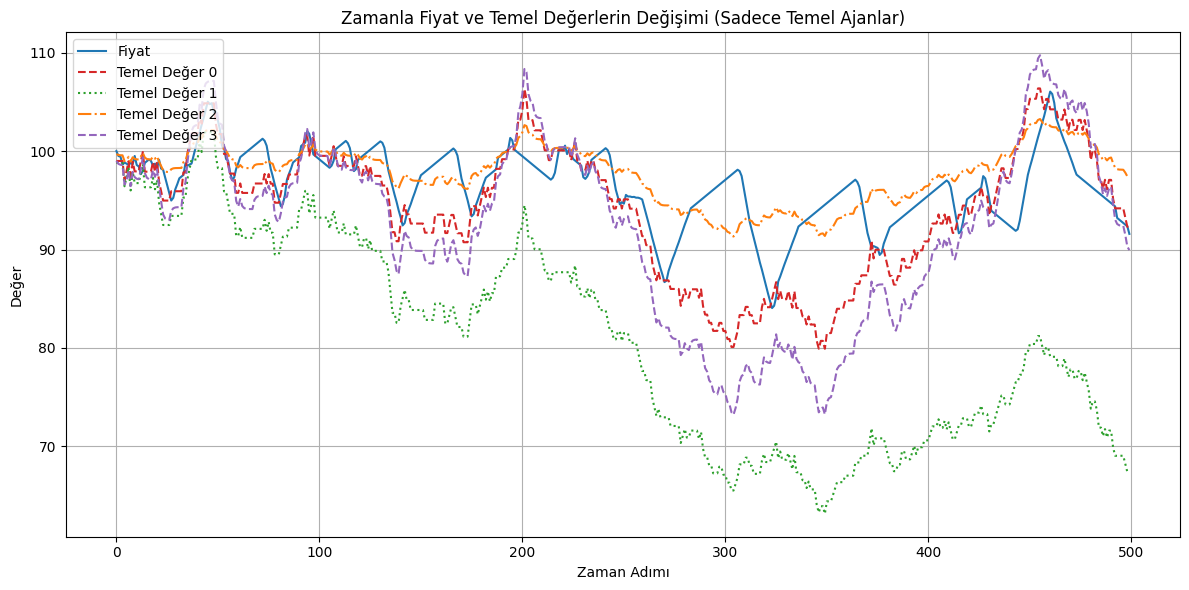

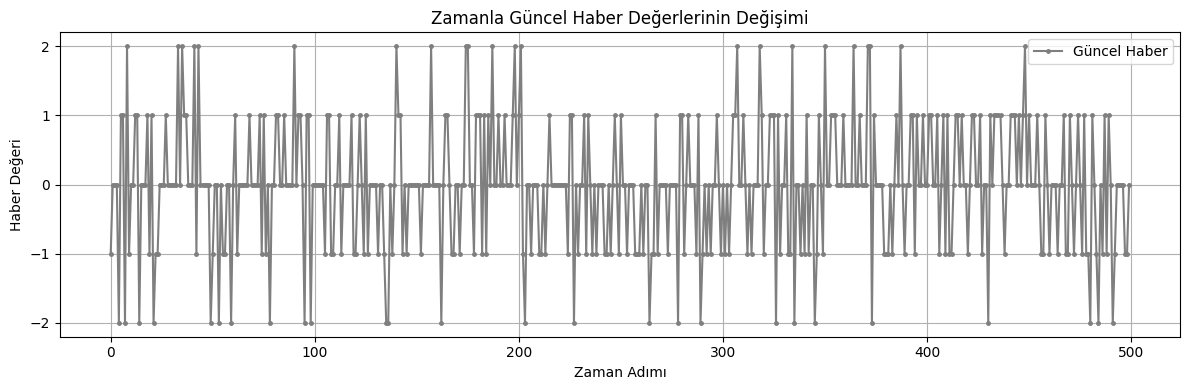

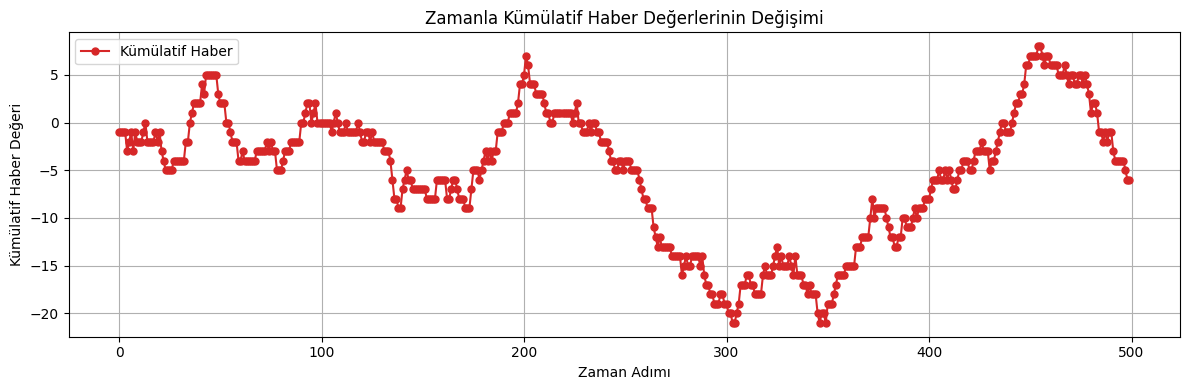

In [151]:
############################### --------SİMÜLASYON VE GÖRSELLEŞTİRME--------###########

import matplotlib.pyplot as plt


# Modeli çalıştır
model = MarketModel(num_fundamental=50, num_technical=200, num_noise=0, seed=12) # Changed num_technical to 400
model.run_model(steps=500) # 100 adım çalıştır

# DataCollector'dan veriyi al
results_df = model.datacollector.get_model_vars_dataframe()


# === Fiyat ve Temel Değerler Grafiği ===
plt.figure(figsize=(12, 6)) # Grafik boyutunu ayarla

# Fiyatı çiz
plt.plot(results_df.index, results_df["Price"], label="Fiyat", color='tab:blue')

# Temel değerleri aynı eksene çiz
plt.plot(results_df.index, results_df["FundamentalValue_0"], label="Temel Değer 0", color='tab:red', linestyle='--')
plt.plot(results_df.index, results_df["FundamentalValue_1"], label="Temel Değer 1", color='tab:green', linestyle=':')
plt.plot(results_df.index, results_df["FundamentalValue_2"], label="Temel Değer 2", color='tab:orange', linestyle='-.')
plt.plot(results_df.index, results_df["FundamentalValue_3"], label="Temel Değer 3", color='tab:purple', linestyle='--')

# Eksen etiketleri ve başlık
plt.xlabel('Zaman Adımı')
plt.ylabel('Değer') # Tek bir Y ekseni için genel başlık
plt.title("Zamanla Fiyat ve Temel Değerlerin Değişimi (Sadece Temel Ajanlar)")

# Grid ekle
plt.grid(True)

# Legend ekle
plt.legend(loc='upper left') # Tüm çizgiler için tek bir legend

plt.tight_layout() # Grafik düzenlemesini otomatik ayarla
plt.show()

# === Haber Değerleri Grafiği (Ayrı Bir Grafik) ===
plt.figure(figsize=(12, 4)) # Haber için daha küçük bir grafik boyutu

# CurrentNews'u çiz
plt.plot(results_df.index, results_df["CurrentNews"],
           label="Güncel Haber",
           color='tab:gray',
           linestyle='-',
           marker='.',
           markersize=5) # Marker boyutunu artır

plt.xlabel('Zaman Adımı')
plt.ylabel('Haber Değeri')
plt.title('Zamanla Güncel Haber Değerlerinin Değişimi')
plt.grid(True)
# Y ekseni tiklerini belirlediğiniz değerlerle ayarla
plt.yticks([-2, -1, 0, 1, 2])
plt.legend()
plt.tight_layout()
plt.show()

# === Kümülatif Haber Grafiği (Yeni Grafik) ===
plt.figure(figsize=(12, 4)) # Grafik boyutu

# CumulatifNews'u çiz
plt.plot(results_df.index, results_df["CumulatifNews"],
           label="Kümülatif Haber",
           color='tab:red', # Farklı bir renk
           linestyle='-',
           marker='o',      # Farklı bir marker
           markersize=5)

plt.xlabel('Zaman Adımı')
plt.ylabel('Kümülatif Haber Değeri')
plt.title('Zamanla Kümülatif Haber Değerlerinin Değişimi')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

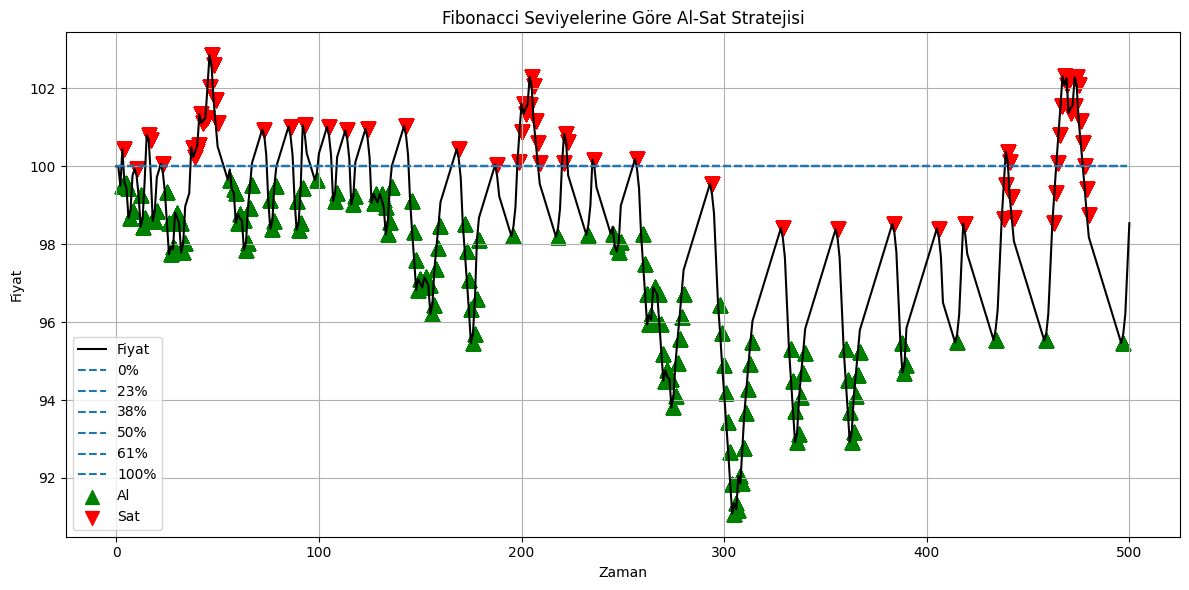

In [148]:
# Altın Oran ve Fibonacci Seviyeleri ile Yatırım Stratejisi
import numpy as np
import matplotlib.pyplot as plt


steps=500
# Görselleştirme
plt.figure(figsize=(12, 6))
plt.plot(model.price_history, label="Fiyat", color='black')
for level, line in zip(model.fib_levels, model.fib_lines):
    plt.hlines(line, 0, steps - 1, linestyles='dashed', label=f'{int(level*100)}%')

buy_t, buy_p = zip(*model.buy_signals) if model.buy_signals else ([], [])
sell_t, sell_p = zip(*model.sell_signals) if model.sell_signals else ([], [])
plt.scatter(buy_t, buy_p, marker='^', color='green', label='Al', s=100)
plt.scatter(sell_t, sell_p, marker='v', color='red', label='Sat', s=100)

plt.title("Fibonacci Seviyelerine Göre Al-Sat Stratejisi")
plt.xlabel("Zaman")
plt.ylabel("Fiyat")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

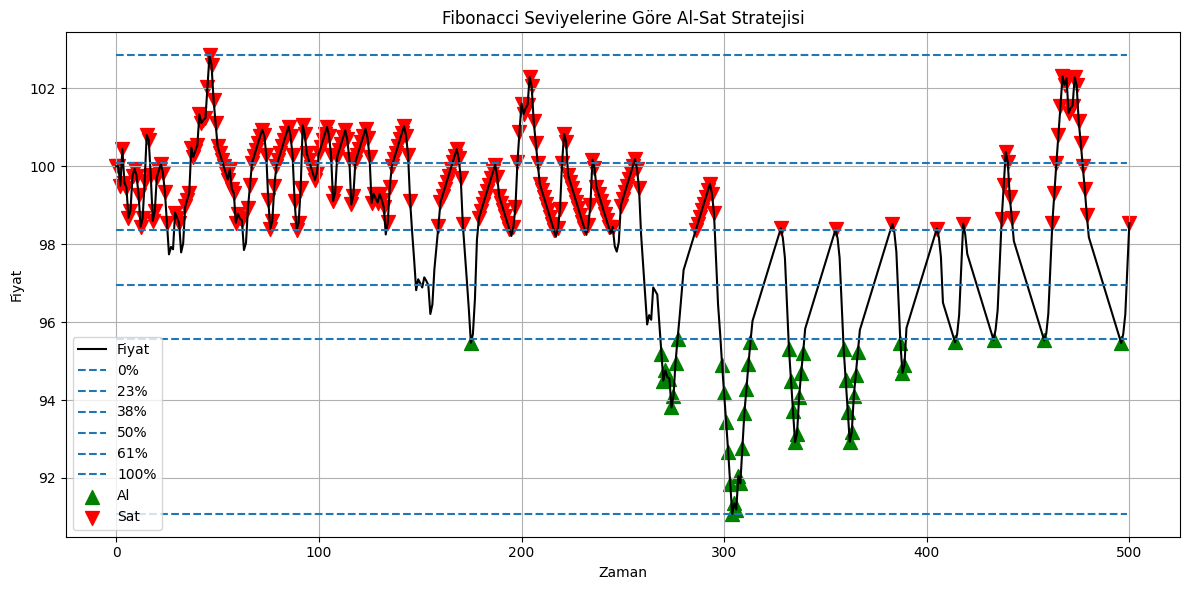

In [149]:
# Altın Oran ve Fibonacci Seviyeleri ile Yatırım Stratejisi
import numpy as np
import matplotlib.pyplot as plt

n_steps = 500

# Fibonacci seviyeleri
max_price = np.max(model.price_history)
min_price = np.min(model.price_history)
fib_levels = [0.0, 0.236, 0.382, 0.5, 0.618, 1.0]
fib_lines = [max_price - (max_price - min_price) * level for level in fib_levels]

# Karar kuralları
actions = []
buy_signals = []
sell_signals = []

for t, price in enumerate(model.price_history):
    if price < fib_lines[4]:  # 0.618 seviyesi
        actions.append("Buy")
        buy_signals.append((t, price))
    elif price > fib_lines[2]:  # 0.382 seviyesi
        actions.append("Sell")
        sell_signals.append((t, price))
    else:
        actions.append("Hold")

# Görselleştirme
plt.figure(figsize=(12, 6))
plt.plot(model.price_history, label="Fiyat", color='black')
for level, line in zip(fib_levels, fib_lines):
    plt.hlines(line, 0, n_steps - 1, linestyles='dashed', label=f'{int(level*100)}%')

buy_t, buy_p = zip(*buy_signals) if buy_signals else ([], [])
sell_t, sell_p = zip(*sell_signals) if sell_signals else ([], [])
plt.scatter(buy_t, buy_p, marker='^', color='green', label='Al', s=100)
plt.scatter(sell_t, sell_p, marker='v', color='red', label='Sat', s=100)

plt.title("Fibonacci Seviyelerine Göre Al-Sat Stratejisi")
plt.xlabel("Zaman")
plt.ylabel("Fiyat")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
